# Lab 1 - K-Nearest Neighbours and Cross Validation

This lab is about the implementation and analysis of the KNN algorithm for classification problems

In [11]:
# Packages used
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import Generator
import pickle


def _check_random_generator(rng: int | Generator | None) -> Generator:
    """Convert rng into a np.random.Generator instance."""
    if rng is None:
        print("⚠️  Warning: Set the `rng` parameter to a NumPy random generator\n"
              "   (e.g. `np.random.default_rng(42)`) or specify a fixed seed to ensure\n"
              "   your results are reproducible. Proceeding with a random seed for now.")
        return np.random.default_rng()
    if isinstance(rng, np.random.Generator):
        return rng
    if isinstance(rng, (int, np.integer)):
        return np.random.default_rng(rng)
    
    raise TypeError(
        "rng must be None, an int seed, or a numpy.random.Generator"
    )

### Data generation for binary classification

We start generating a training set for binary classification problems. Consider the following function, that generates random 2D points on the plane and assigns them a binary label according to their position w.r.t. a linear separator.

The function `linearBinaryClass`, given a sample size `n`, lower and upper bounds `low_D, high_D` for the domain of the samples and the linear function parameters `m, q`, generates a binary classification dataset, i.e., it returns `X` and `Y`.

The signature of the function is the following:

`X, Y = linearBinaryClass(n, low_D, high_D, m, q)`

where
- **n** is the number of samples to be generated
- **low_D** and **high_D** are, respectively, the lower and upper bounds for the domain of the samples i.e.
    $$
    X_{i,j} \sim \mathcal{U}(\text{low\_D}, \text{high\_D})
    $$
- **m, q** are the linear function parameters
- **X**, **Y**: 2-dimensional samples (X) associated with 1-dimensional binary labels (Y)


In [12]:
def linearBinaryClass(n, low_D, high_D, m, q, rng: int | Generator | None = None):
    rng = _check_random_generator(rng)
    X = (rng.random((n, 2)) * (high_D - low_D)) + low_D
    Y = np.sign((X[:,1] - (m * X[:,0]) + q))
    Y[Y==0] = 1
    return X,Y

### Computing the distance between input points

In order to build the KNN estimator we need to resort to a distance function.

Consider a function that computes the euclidean distance between two points...

In [13]:
def euclidDistance(P1,P2):
    return np.linalg.norm(P1-P2,2)

... and then a function that computes all the distances between two set of points stored in two matrices.

In [14]:
def allDistances(X1, X2):
    D = np.zeros((X1.shape[0], X2.shape[0]))
    for i in range(D.shape[0]):
        for j in range(D.shape[1]):
            D[i, j] = euclidDistance(X1[i], X2[j])
    # This is slow, it can be optimized. 
    return D

The usage is the following:

**D = allDistances(X1,X2)**

where
- **X1** is a matrix of size $n_1 \times D$, where each row is a D-dimensional point
- **X2** is a matrix of size $n_2 \times D$, where each row is a D-dimensional point
- **D** is a matrix of size $n_1 \times n_2$, where each element `D[i,j]` is the distance between points (`X1[i, :]`, `X2[j, :]`)

### Adding noise to the samples

To make the task harder, we may want to perturb the labels with some noise.

In our case, we have binary labels and a common way of adding noise is to flip the value of a small percentage of the labels. For example, if a label was $+1$ it will become $-1$.

The `flipLabels` function takes two arguments:
 - `Y`, the numpy array of original labels
 - `P`, an integer between 1 and 100 specifying the percentage of labels which will be flipped
and returns an array of the same shape as `Y`, which contains the noisy labels.


In [15]:
def flipLabels(Y, P: int, rng: int | Generator | None = None):
    assert 0 <= P <= 100, 'P should be between 0 and 100'
    if P == 0:
        return Y
    rng = _check_random_generator(rng)
    ny = len(Y)
    indices_to_flip = rng.choice(range(ny), int(ny * (P / 100)), replace=False)
    Y_noisy = Y.copy()
    Y_noisy[indices_to_flip] *= -1
    return Y_noisy

### Visualize the dataset

A utiliy function to visualize the dataset for binary classification

In [24]:
n = 20
low_D = -3
high_D = 3
m = 0.5
q = 0.5 
Xd, Yd = linearBinaryClass(n, low_D, high_D, m, q, 42)

In [16]:
def plotData(Xd, Yd):
    x = Xd[:, 0]
    y = Xd[:, 1]
    plt.scatter(x[Yd==1], y[Yd==1], c="#C59434", marker='o', s=50, zorder=10, alpha=0.8)
    plt.scatter(x[Yd==-1], y[Yd==-1], c="#092C48", marker='o', s=50, zorder=10, alpha=0.8)
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    plt.show()

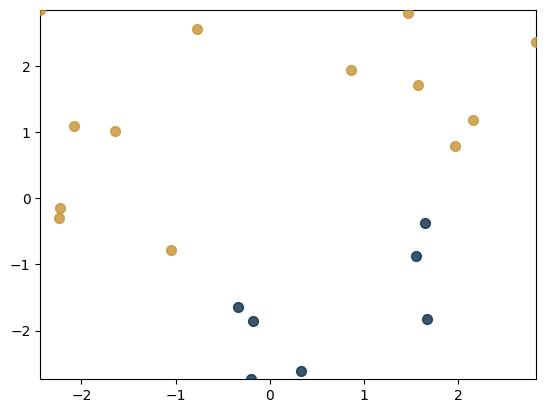

In [26]:
plotData(Xd, Yd)

In [31]:
np.sign(3)

np.int64(1)

### The KNN classifier

We are now ready to use the KNN algorithm to estimate the classification function. 

Implement the `kNNClassify` function which train a KNN classifier on given training set and returns predictions on a given test set. 

The signature of the function is the following:

`Ypred = kNNClassify(Xtr, Ytr, k, Xte)`

where
- **Xtr** is a matrix of size [ntr, D], where each row is a D-dimensional point (INPUT IN THE **TRAINING SET**)
- **Ytr** is an array of size [ntr], where each element is a binary label (OUTPUT IN THE **TRAINING SET**)
- **k** is the number of neighbours to be considered
- **Xte** is a matrix of size [nte, D], where each row is a D-dimensional point (INPUT IN THE **TEST SET**)
- **Ypred** is an array of size [nte], where each element is a binary label (ESTIMATED OUTPUT FOR THE **TEST SET**)

where [ntr] and [nte] are respectively the number of points in the training set and the number of points in the test set

In [17]:
def kNNClassify(Xtr, Ytr, k, Xte):

    n_train = Xtr.shape[0] # number of the training inputs
    n_test = Xte.shape[0]  # number of the test inputs

    if any(np.abs(Ytr) != 1):
        raise Exception("The values of Ytr should be +1 or -1.")

    if k > n_train:
        print("k is greater than the number of points, setting k=n_train")
        k = n_train

    Ypred = np.zeros(n_test)

    # Compute all the distances from TEST input and TRAINING input
    dist = allDistances(Xte, Xtr) 
    
    # For each test point, the predicted class will be 
    # the sign of the average label of the k nearest points
    for idx in range(n_test):
        distances = dist[idx] 
        sorted_distances = np.argsort(distances) 
        k_nearest_indices = sorted_distances[:k]
        k_nearest_labels = Ytr[k_nearest_indices]
        Ypred[idx] = np.sign(np.mean(k_nearest_labels))
        if Ypred[idx] == 0:
            Ypred[idx] = 1
            
    return Ypred


### Visualizing the separating function

The visualization of the separating function on the training set, i.e. the function estimated by classification algorithm for discriminating between classes, is of benefit for appreciating the behavior of the binary classifier. To visualize the separating function use the following:

**_separatingFkNN(Xtr, Ytr, k, Xte, Yte)_**

where
- **Xtr** is a matrix of size [ntr, D], where each row is a D-dimensional point (INPUT IN THE **TRAINING SET**)
- **Ytr** is an array of size [ntr], where each element is a binary label (OUTPUT IN THE **TRAINING SET**)
- **k** is the number of neighbours to be considered
- **Xte** is a matrix of size [nte, D], where each row is a D-dimensional point (INPUT IN THE **TEST SET**)
- **Yte** is an array of size [nte], where each element is a binary label (OUTPUT IN THE **TEST SET**)


In [18]:
def separatingFkNN(Xtr, Ytr, k, Xte, Yte):
    x1min, x1max = min(Xtr[:, 0]), max(Xtr[:, 0])
    x2min, x2max = min(Xtr[:, 1]), max(Xtr[:, 1])

    # Number of mesh points for visualization
    Nx1, Nx2 = 100, 100
    x1mesh = np.linspace(x1min, x1max, Nx1)
    x2mesh = np.linspace(x2min, x2max, Nx2)

    # Create mesh and reshape x1 and x2 into a single array of points
    x1, x2 = np.meshgrid(x1mesh, x2mesh)
    meshpoints = np.column_stack((x1.ravel(), x2.ravel()))

    # Run kNN classifier on mesh points
    ypred = kNNClassify(Xtr, Ytr, k, meshpoints)

    plt.subplots()
    plt.contour(x1mesh, x2mesh, np.reshape(ypred, (Nx2, Nx1)), levels=[0])

    # Optionally plot training data
    # plt.scatter(Xtr[:, 0], Xtr[:, 1], c=Ytr, marker='o', s=50, zorder=10, alpha=0.8)

    # Plot test points
    plt.scatter(Xte[Yte==1, 0], Xte[Yte==1, 1], c="#C59434", marker='o', s=50, zorder=10, alpha=0.8)
    plt.scatter(Xte[Yte==-1, 0], Xte[Yte==-1, 1], c="#092C48", marker='o', s=50, zorder=10, alpha=0.8)

    plt.xlim(x1min, x1max)
    plt.ylim(x2min, x2max)
    plt.title(f"Separating function, k={k}")
    plt.show()

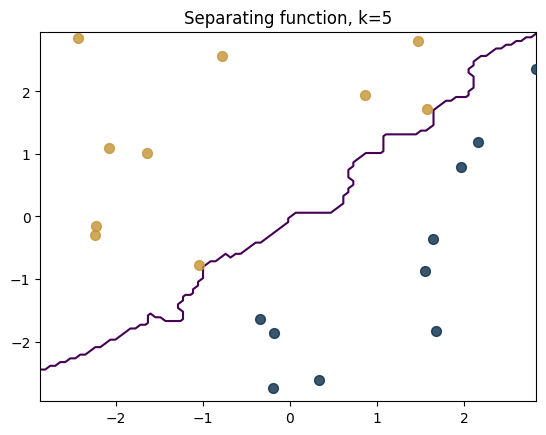

In [51]:
n_train = 100
n_test = 20
low_D = -3
high_D = 3 
m = 1
q = 0
rng = 42
Xtr, Ytr = linearBinaryClass(n_train, low_D, high_D, m, q, rng)
Xte, Yte = linearBinaryClass(n_test, low_D, high_D, m, q, rng) 
separatingFkNN(Xtr, Ytr, 5, Xte, Yte)

### Evaluating the goodness of a classifier

To evaluate how good is the classification function estimated by the KNN, we compare the predicted binary labels and expected (true) ones, with the following function:

`err = calcError(Ypred, Ytrue)`

where
- **Ypred** is an array of size $n$, where each element is a binary label predicted by the classifier
- **Ytrue** is an array of size $n$, where each element is the true binary label
- **err** is the fraction of wrongly classified elements wrt the total number


In [19]:
def calcError(Ypred, Ytrue):
    return (np.count_nonzero(Ypred != Ytrue)) / len(Ytrue)

### Analysis: Noise-free case

In this assignment, we start to play with the NN classifier. In specific:

- 1.Generate a training set WITHOUT NOISE
- 2.Visualize the separating curve for the **NN** classifier 
- 3.Generate a test set with the same amount of noise as the training set.
- 4.Compute the error on the TRAINING and then on the TEST SET



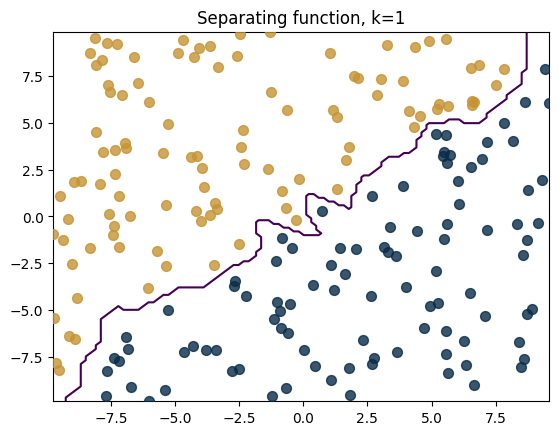

With K=1 the error on the test set is 0.030
With K=1 the error on the training set is 0.000


In [62]:
### Generate training and test sets, build and evaluate the KNN classifier
n = 200

m = 0.9
q = 0.0

low_D = -10
high_D = 10

k = 1

#TODO: Generate a training set WITHOUT NOISE
Xtr, Ytr = linearBinaryClass(n, low_D, high_D, m, q, 42) 

#TODO: Visualize the separating curve for the NN classifier on the TRAINING SET
separatingFkNN(Xtr, Ytr, k, Xtr, Ytr) 

#TODO: Generate a test set WITHOUT NOISE
Xte, Yte = linearBinaryClass(n, low_D, high_D, m, q, 37)  

#TODO: Evaluate the NN classifier on the TEST SET
Ypred = kNNClassify(Xtr, Ytr, k, Xte) 

#TODO: Compute the error on the TEST SET
err = calcError(Yte, Ypred) 

print(f"With K={k} the error on the test set is {err:.3f}")

# How the classifier perform on the TRAINING SET instead?
Ypredtr = kNNClassify(Xtr, Ytr, k, Xtr)
errtr = calcError(Ytr, Ypredtr)
print(f"With K={k} the error on the training set is {errtr:.3f}")

### Analysis: adding noise

Keeping the parameters of the function and the number of points as in the previous assignment:

- 1.Generate a training set WITH NOISE (for instance with 10% of flipped labels)
- 2.Visualize the separating curve for the **NN** classifier 
- 3.Generate a test set with the same amount of noise as the training set.
- 4.Evaluate the NN classifier on the TRAINING and on the TEST SET
- 5.Compute the obtained error on the TRAINING and on the TEST SET

- Repeat the steps from 1 to 5 with the **KNN** algorithm, setting for instance K=5

OBSERVE WHAT CHANGES...

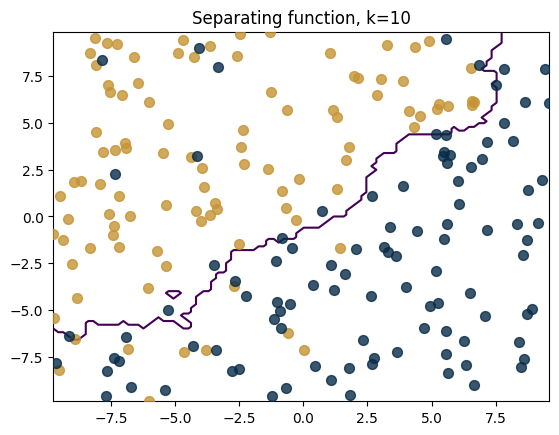

With K=10 the error on the training set is 0.110
With K=10 the error on the test set is 0.125


In [66]:
P = 10 
k = 10 # 6. Change the value of K. 
Ytr_noisy = flipLabels(Ytr, P, 42) # 1. Noisy labels for training 

separatingFkNN(Xtr, Ytr_noisy, k, Xtr, Ytr_noisy) # 2. Visualizing the decision border. 

Yte_noisy = flipLabels(Yte, P, 37) # 3. Noisy labels for testing. 

Ytr_pred = kNNClassify(Xtr, Ytr_noisy, k, Xtr) # 4. Predictions on the training set.
errtr_noisy = calcError(Ytr_noisy, Ytr_pred) # 5. Error on the training set. 
print(f"With K={k} the error on the training set is {errtr_noisy:.3f}")

Yte_pred = kNNClassify(Xtr, Ytr_noisy, k, Xte) # 4. Predictions on the test set.
err_te_noisy = calcError(Yte_noisy, Yte_pred) # 5. Error on the test set.

print(f"With K={k} the error on the test set is {err_te_noisy:.3f}") 

Increasing the ammount of neighbours diminishes the number and size of the isles caused by noise. 

### Analysis: comparison of different scenarios

Analyse the performance of the **KNN** with plots, considering in particular the following:



- **SCENARIO 1**: Fix the number n of points to 200, fix the amount of noise to 10%, and plot the performance of the KNN classifier on TRAINING and TEST SETS as you increase the value of K

- **SCENARIO 2**: Fix the number n of points to 200, fix the value of K to a reasonable number of neighbours, and plot the performance of the KNN classifier on TRAINING and TEST SETS as you increase the amount of noise

- **SCENARIO 3**: Fix noise and K to two reasonable values, fix the number of TEST samples to 300, and plot the performance of the KNN classifier on TRAINING and TEST SETS as you increase the number of TRAINING samples (e.g. from 30 to 300 with steps 30)

For each scenario, describe what happen

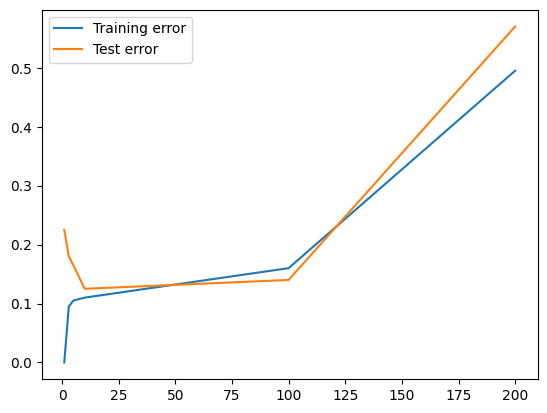

In [75]:
n = 200
P = 10 
low_D = -10
high_D = 10 
m = 0.9
q = 0.0 
Xtr, Ytr = linearBinaryClass(n, low_D, high_D, m, q, 42)
Xte, Yte = linearBinaryClass(n, low_D, high_D, m, q, 37) 
Ytr_noisy = flipLabels(Ytr, P, 42)
Yte_noisy = flipLabels(Yte, P, 37) 

k_pos = [1, 3, 5, 10, 100, 200] # A list of k's to test performance. 
tr_errors_list = np.zeros(len(k_pos))
te_errors_list = np.zeros(len(k_pos))  
for idx, k in enumerate(k_pos):
    Ytr_pred = kNNClassify(Xtr, Ytr_noisy, k, Xtr) 
    errtr_noisy = calcError(Ytr_noisy, Ytr_pred) 
    tr_errors_list[idx] = errtr_noisy
    
    Yte_pred = kNNClassify(Xtr, Ytr_noisy, k, Xte) 
    err_te_noisy = calcError(Yte_noisy, Yte_pred) 
    te_errors_list[idx] = err_te_noisy
plt.plot(k_pos, tr_errors_list, label="Training error")
plt.plot(k_pos, te_errors_list, label="Test error")
plt.legend()
plt.show()


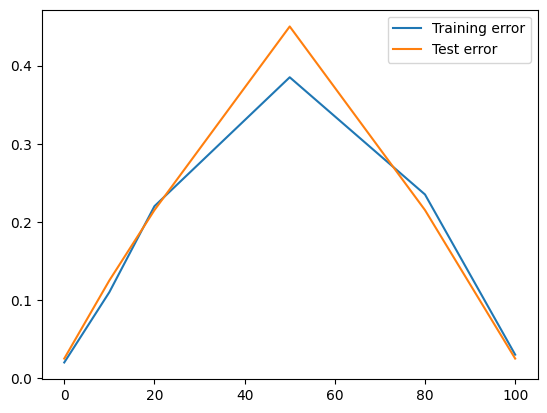

In [76]:
n = 200
K = 10  
low_D = -10
high_D = 10 
m = 0.9
q = 0.0 
Xtr, Ytr = linearBinaryClass(n, low_D, high_D, m, q, 42)
Xte, Yte = linearBinaryClass(n, low_D, high_D, m, q, 37) 
P_pos = [0, 10, 20, 50, 80, 100] # A list of noise levels to test performance.

tr_errors_list = np.zeros(len(P_pos))
te_errors_list = np.zeros(len(P_pos))  
for idx, P in enumerate(P_pos):
    Ytr_noisy = flipLabels(Ytr, P, 42)
    Yte_noisy = flipLabels(Yte, P, 37) 
    Ytr_pred = kNNClassify(Xtr, Ytr_noisy, K, Xtr) 
    errtr_noisy = calcError(Ytr_noisy, Ytr_pred) 
    tr_errors_list[idx] = errtr_noisy
    
    Yte_pred = kNNClassify(Xtr, Ytr_noisy, K, Xte) 
    err_te_noisy = calcError(Yte_noisy, Yte_pred) 
    te_errors_list[idx] = err_te_noisy
plt.plot(P_pos, tr_errors_list, label="Training error")
plt.plot(P_pos, te_errors_list, label="Test error")
plt.legend()
plt.show()


k is greater than the number of points, setting k=n_train
k is greater than the number of points, setting k=n_train


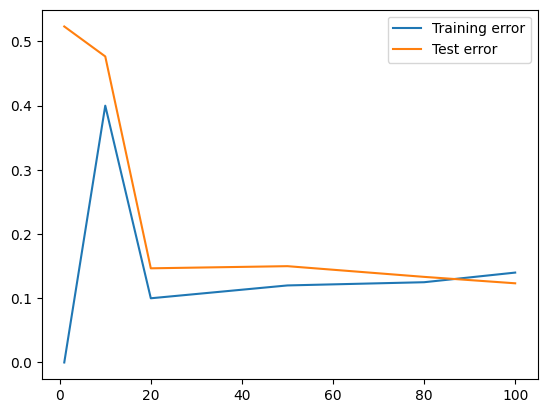

In [77]:
n_test = 300
K = 10  
P = 10
low_D = -10
high_D = 10 
m = 0.9
q = 0.0 
Xte, Yte = linearBinaryClass(n_test, low_D, high_D, m, q, 37) 
Yte_noisy = flipLabels(Yte, P, 37) 
n_pos = [1, 10, 20, 50, 80, 100] # A list of noise levels to test performance.

tr_errors_list = np.zeros(len(n_pos))
te_errors_list = np.zeros(len(n_pos))  
for idx, n_train in enumerate(n_pos):
    Xtr, Ytr = linearBinaryClass(n_train, low_D, high_D, m, q, 42)
    Ytr_noisy = flipLabels(Ytr, P, 42)
    Ytr_pred = kNNClassify(Xtr, Ytr_noisy, K, Xtr) 
    errtr_noisy = calcError(Ytr_noisy, Ytr_pred) 
    tr_errors_list[idx] = errtr_noisy
    
    Yte_pred = kNNClassify(Xtr, Ytr_noisy, K, Xte) 
    err_te_noisy = calcError(Yte_noisy, Yte_pred) 
    te_errors_list[idx] = err_te_noisy
plt.plot(n_pos, tr_errors_list, label="Training error")
plt.plot(n_pos, te_errors_list, label="Test error")
plt.legend()
plt.show()


Insert here your observations:
- **SCENARIO 1**:
- **SCENARIO 2**:
- **SCENARIO 3**:


### Selecting the hyperparameter with Cross-Validation

In this part we apply cross-validation to select the best value of the hyperparameter K. To this purpose, we suggest you use the following datasets we already collected for you (see folder Material):

  - (Training1, Test1): n=70, no noise, suggested K values are in the range 1 ... 13
  - (Training2, Test2): n=40, no noise, suggested K values are in the range 1 ... 23
  - (Training3, Test3): n=200, 20% flipped labels, suggested K values are in the range 1 ... 31
  - (Training4, Test4): n=200, 5% flipped labels, suggested K values are in the range 1 ... 19

Note that each dataset includes both a training and a test set. You **cannot use the test set to choose k**: you should assume you don't have access to the test set when doing model selection!

To load a dataset use function
`Xtr, Ytr, Xte, Yte = load_dataset(path_tr, path_te)`

Where:
- **_path\_tr_**: is the path to the file which contains the training set
- **_path\_te_**: is the path to the file which contains the test set

and it returns:
- **_Xtr_**: Inputs of training set
- **_Ytr_**: Outputs of training set
- **_Xte_**: Inputs of test set
- **_Yte_**: Outputs of test set

In [20]:
# This is the utility function to load the dataset
def load_dataset(path_tr, path_te):
    with open(path_tr,"rb") as f:
        [Xtr, Ytr] = pickle.load(f)
    with open(path_te,"rb") as f:
        [Xte, Yte] = pickle.load(f)
    return Xtr, Ytr, Xte, Yte

### K-Fold cross validation

In K-Fold cross validation, the data are split into K parts of approximately equal size, and K different models are trained each time leaving out one of the parts of data. Then the estimate for the test error is the mean of the error of the K different models.

In [21]:
def KFoldCVkNN(Xtr, Ytr, num_folds, k_list, rng: int | Generator | None = None):
    """Run K-Fold CV for the kNN model

    Parameters:
    -----------
     - Xtr : np.array
         the full training set data
     - Ytr : np.array
         the full training set labels
     - num_folds : int
         the number of folds
     - k_list : List[int] | range | np.ndarray
         the values of k (for k-NN) to try
     - rng : Optional[int | Generator | None]
         optional random state

    Returns:
    --------
     - best_k : int
         The value of k (in k_list) which obtains the best average validation error
     - best_k_idx : int
         The index of best_k in k_list
     - tr_err_mean : np.array
         A 1D array of the same length as k_list, with the average training error for each k
     - tr_err_std : np.array
         A 1D array of the same length as k_list, with the training error std-dev for each k
     - val_err_mean : np.array
         A 1D array of the same length as k_list, with the average validation error for each k
     - val_err_std : np.array
         A 1D array of the same length as k_list, with the validation error std-dev for each k
    """
    rng = _check_random_generator(rng)
    k_list = np.asarray(list(k_list), dtype=int)

    n = Xtr.shape[0]
    if num_folds < 2 or num_folds > n:
        raise ValueError("num_folds must be at least 2 and at most the number of samples")

    # Shuffle indices, then split into folds
    indices = rng.permutation(n)
    folds = np.array_split(indices, num_folds)

    tr_errors = np.zeros((len(k_list), num_folds))
    val_errors = np.zeros((len(k_list), num_folds))

    for fold_idx in range(num_folds):
        val_idx = folds[fold_idx]
        tr_idx = np.hstack([folds[j] for j in range(num_folds) if j != fold_idx])

        # TODO: Split the training set into a training fold and a validation fold 
        X_train, Y_train = Xtr[tr_idx], Ytr[tr_idx]
        X_val, Y_val = Xtr[val_idx], Ytr[val_idx]

        for k_idx, k in enumerate(k_list):
            # TODO: Compute the predicted labels and the training error
            Ypred_tr = kNNClassify(X_train, Y_train, k, X_val)
            tr_errors[k_idx, fold_idx] = calcError(Ypred_tr, Y_train)

            # TODO: Compute the predicted labels and the validation error
            Ypred_val = kNNClassify(X_train, Y_train, k, X_val)
            val_errors[k_idx, fold_idx] = calcError(Ypred_val, Y_val)

    # Statistics across folds
    tr_err_mean = np.mean(tr_errors, axis=1)
    tr_err_std = np.std(tr_errors, axis=1)
    val_err_mean = np.mean(val_errors, axis=1)
    val_err_std = np.std(val_errors, axis=1)

    best_k_idx = int(np.argmin(val_err_mean))
    best_k = int(k_list[best_k_idx])

    return best_k, best_k_idx, tr_err_mean, tr_err_std, val_err_mean, val_err_std


In [25]:
# Now we call the K-Fold Cross Validation on one of the dataset, for instance the first one
Xtr, Ytr, Xte, Yte = load_dataset(
    "Training1.dat", "Test1.dat")
rng = 42
num_folds = 5
k_list = range(1, 13, 2)
best_k, best_k_idx, tr_err_mean, tr_err_std, val_err_mean, val_err_std = KFoldCVkNN(
    Xtr, Ytr, num_folds, k_list, rng)

print(f"The best k chosen with {num_folds} folds is {best_k} with error "
      f"{np.min(val_err_mean) * 100:.2f} +- {val_err_std[np.argmin(val_err_mean)] * 100:.2f}%")

C:\Users\LS.5074195\AppData\Local\Temp\ipykernel_18656\3256790057.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  [Xtr, Ytr] = pickle.load(f)
C:\Users\LS.5074195\AppData\Local\Temp\ipykernel_18656\3256790057.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  [Xte, Yte] = pickle.load(f)


ValueError: operands could not be broadcast together with shapes (14,) (56,) 

In [ ]:
# We plot the training e validation error
fig, ax = plt.subplots()
ax.plot(k_list, val_err_mean, label="Validation")
ax.fill_between(k_list, val_err_mean - val_err_std, val_err_mean + val_err_std, alpha=0.2)
ax.plot(k_list, tr_err_mean, label="Training")
ax.fill_between(k_list, tr_err_mean - tr_err_std, tr_err_mean + tr_err_std, alpha=0.2)

ax.set_title(f"{num_folds}-Fold CV")
ax.set_ylabel("Error")
ax.set_xlabel("k")
ax.legend();

Compare the curves of the training and validation error: what can you observe?

In [ ]:
# Finally, evaluate the model with the best k on the test set now
Ypred = kNNClassify(Xtr, Ytr, best_k, Xte)
te_err = calcError(Ypred, Yte)

print(f"The test error with the best k ({best_k}) is: {te_err*100:.3f}%")

### Cross validation and Noise in k-NN

In this final task we consider the effect of noise on the best k (chosen with k-fold CV).

We will use dataset3 which has high noise (20%), and dataset4 which has low noise (5%).

You will have to do the following:
 1. Use k-fold CV to find the best k for datasets 3 and 4.
 2. Compare the obtained values of k, with the actual best k on the test error of the two datasets. This should be a sanity check: if the errors on k-fold CV and on the test set are very different, something may be wrong with your code.
 3. Comment on how noise affects the best k: does a more noisy dataset need a higher or a lower k, and why? It may be useful to plot the separating function (using the `separatingFkNN` function) of k-NN with the best k for the two datasets.

In [ ]:
# ... your code goes here... #